# 📘 Notebook 6: Credit Approval Dataset (UCI)
**Fuente:** https://archive.ics.uci.edu/dataset/27/credit+approval

Dataset anonimizado de aprobación de crédito con variables numéricas y categóricas mezcladas. Los atributos han sido ofuscados por razones de confidencialidad.

## Introducción
El **Credit Approval Dataset** contiene 690 instancias con 15 atributos (mezcla de numéricos y categóricos, completamente anonimizados). La variable objetivo indica si una solicitud de crédito fue aprobada (`+`) o rechazada (`-`). Es un problema de **clasificación binaria**. Contiene valores faltantes representados como `?`.

##  Carga del Dataset

In [2]:
import os
import pandas as pd
import numpy as np

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    EXPORT_PATH = '/content/drive/MyDrive/datasets/credit_approval/'
else:
    EXPORT_PATH = './credit_approval_output/'

os.makedirs(EXPORT_PATH, exist_ok=True)

URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/credit-screening/crx.data'

COLUMNS = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10','A11','A12','A13','A14','A15','A16']

df = pd.read_csv(URL, header=None, names=COLUMNS, na_values='?')
print(f'Dataset cargado: {df.shape}')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado: (690, 16)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


## Identificación del Tipo de Problema

In [3]:
TARGET = 'A16'
print(f'Variable objetivo: {TARGET}')
print(f'Valores únicos: {df[TARGET].unique()}')
print(f'Distribución:\n{df[TARGET].value_counts()}')
print('\n→ Tipo de problema: CLASIFICACIÓN BINARIA (+ = aprobado, - = rechazado)')

Variable objetivo: A16
Valores únicos: ['+' '-']
Distribución:
A16
-    383
+    307
Name: count, dtype: int64

→ Tipo de problema: CLASIFICACIÓN BINARIA (+ = aprobado, - = rechazado)


## Análisis Exploratorio (EDA)

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

df.info()
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    object 
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      684 non-null    object 
 4   A5      684 non-null    object 
 5   A6      681 non-null    object 
 6   A7      681 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    int64  
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     677 non-null    float64
 14  A15     690 non-null    int64  
 15  A16     690 non-null    object 
dtypes: float64(4), int64(2), object(10)
memory usage: 86.4+ KB


,A2,A3,A8,A11,A14,A15
count,678.000000,690.000000,690.000000,690.00000,677.000000,690.000000
mean,31.568171,4.758725,2.223406,2.40000,184.014771,1017.385507
std,11.957862,4.978163,3.346513,4.86294,173.806768,5210.102598
min,13.750000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,22.602500,1.000000,0.165000,0.00000,75.000000,0.000000
50%,28.460000,2.750000,1.000000,0.00000,160.000000,5.000000
75%,38.230000,7.207500,2.625000,3.00000,276.000000,395.500000
max,80.250000,28.000000,28.500000,67.00000,2000.000000,100000.000000


In [5]:
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
A1     12
A2     12
A3      0
A4      6
A5      6
A6      9
A7      9
A8      0
A9      0
A10     0
A11     0
A12     0
A13     0
A14    13
A15     0
A16     0
dtype: int64


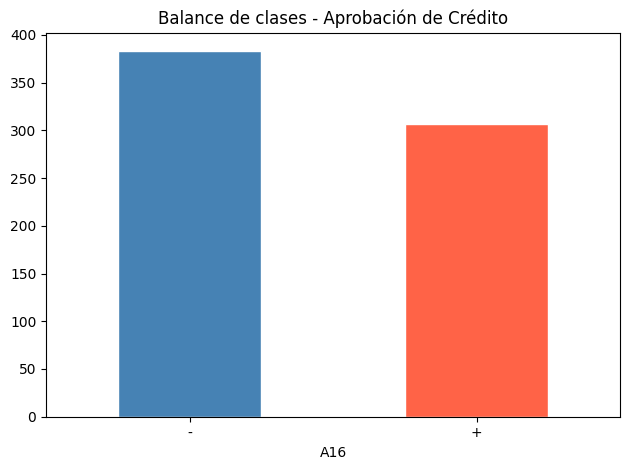

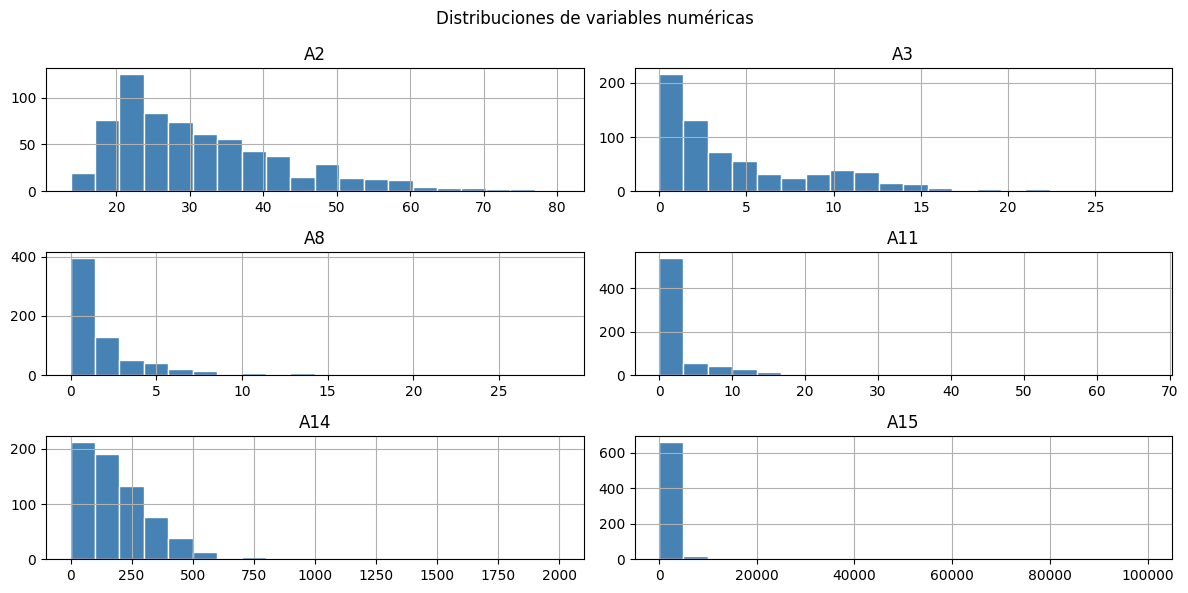

In [6]:
# Balance de clases
df[TARGET].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='white')
plt.title('Balance de clases - Aprobación de Crédito')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Distribuciones numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols].hist(figsize=(12, 6), bins=20, color='steelblue', edgecolor='white')
plt.suptitle('Distribuciones de variables numéricas')
plt.tight_layout()
plt.show()

## Limpieza y Preparación

In [8]:
df_clean = df.copy()

print(f'Duplicados: {df_clean.duplicated().sum()}')
df_clean = df_clean.drop_duplicates()

# Detectar tipos
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET]
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

# Imputar nulos numéricos con mediana
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
        print(f'  {col}: imputado con mediana')

# Imputar nulos categóricos con moda
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
        print(f'  {col}: imputado con moda')

print(f'\nNulos restantes: {df_clean.isnull().sum().sum()}')
print(f'Shape: {df_clean.shape}')

Duplicados: 0
  A2: imputado con mediana
  A14: imputado con mediana
  A1: imputado con moda
  A4: imputado con moda
  A5: imputado con moda
  A6: imputado con moda
  A7: imputado con moda

Nulos restantes: 0
Shape: (690, 16)


/tmp/ipykernel_14003/3080353924.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)
/tmp/ipykernel_14003/3080353924.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

## Transformación y Preprocesamiento

In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_processed = df_clean.copy()

# Codificar target
df_processed[TARGET] = (df_processed[TARGET] == '+').astype(int)
print(f'Target codificado: 1=aprobado, 0=rechazado')
print(df_processed[TARGET].value_counts())

le = LabelEncoder()
for col in cat_cols:
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))

all_num = [c for c in df_processed.columns if c != TARGET]
scaler = StandardScaler()
df_processed[all_num] = scaler.fit_transform(df_processed[all_num])

print(f'Shape preprocesado: {df_processed.shape}')
df_processed.head()

Target codificado: 1=aprobado, 0=rechazado
A16
0    383
1    307
Name: count, dtype: int64
Shape preprocesado: (690, 16)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,0.661438,-0.057723,-0.956613,-0.54295,-0.559499,1.471393,0.757878,-0.291083,0.95465,1.157144,-0.288101,-0.919195,-0.317171,0.107155,-0.195413,1
1,-1.511858,2.291317,-0.060051,-0.54295,-0.559499,1.004392,-0.836439,0.244190,0.95465,1.157144,0.740830,-0.919195,-0.317171,-0.816912,-0.087852,1
2,-1.511858,-0.591826,-0.856102,-0.54295,-0.559499,1.004392,-0.836439,-0.216324,0.95465,-0.864196,-0.493887,-0.919195,-0.317171,0.560471,-0.037144,1
3,0.661438,-0.310853,-0.647038,-0.54295,-0.559499,1.471393,0.757878,0.456505,0.95465,1.157144,0.535044,1.087908,-0.317171,-0.485643,-0.194837,1
4,0.661438,-0.957176,0.174141,-0.54295,-0.559499,1.471393,0.757878,-0.153526,0.95465,-0.864196,-0.493887,-0.919195,3.270501,-0.369408,-0.195413,1


## División Train/Test (80/20, stratify)

In [10]:
from sklearn.model_selection import train_test_split

X = df_processed.drop(columns=[TARGET])
y = df_processed[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

train_df = X_train.copy(); train_df[TARGET] = y_train.values
test_df  = X_test.copy();  test_df[TARGET]  = y_test.values

print(f'Train: {train_df.shape}  |  Test: {test_df.shape}')
print(f'Proporción aprobados - Train: {y_train.mean():.3f}  |  Test: {y_test.mean():.3f}')

Train: (552, 16)  |  Test: (138, 16)
Proporción aprobados - Train: 0.446  |  Test: 0.442


## Exportación de train.csv y test.csv

In [11]:
train_df.to_csv(os.path.join(EXPORT_PATH, 'train.csv'), index=False)
test_df.to_csv(os.path.join(EXPORT_PATH, 'test.csv'), index=False)
print(f'✅ train.csv guardado: {train_df.shape}')
print(f'✅ test.csv  guardado: {test_df.shape}')

✅ train.csv guardado: (552, 16)
✅ test.csv  guardado: (138, 16)
